# US Automotive Market Dynamics: Inventory, Sales, and Inflation (2024 – Present)

## US Vehicle Ecosystem: Supply Elasticity, Moving Averages, and Price Pressures

### Description

This notebook delivers a granular visual tracking of the contemporary U.S. automotive market landscape. Utilizing key datasets from the Federal Reserve Economic Data (FRED), the analysis synthesizes:

- **Auto Inventory to Sales Ratio (`AISRSA`):** Measures market balance showing how many months current vehicle stock can sustain ongoing sales volumes.
- **Domestic Vehicle Inventory (`AUINSA`):** Tracks raw unit volume additions to dealerships alongside a 3-month trailing moving average of monthly net changes.
- **Total Vehicle Sales (`TOTALSA`):** Quantifies consumer demand velocity measured at a seasonally adjusted annual rate (SAAR).
- **New Vehicle CPI Inflation (`CUSR0000SETA01`):** Captures real-time pricing power dynamics using the year-over-year consumer price percentage change.

---

## Objectives

- Assess post-2024 supply chain normalization via absolute inventory volumes vs. operational sales speeds.
- Isolate the momentum of vehicle demand shifts using a 3-month smoothed moving average delta.
- Contrast retail vehicle price shifts against physical dealer lot inventory trends to map supply-demand economic principles.

---

## Data Sources

- Federal Reserve Economic Data (FRED)
  - `AISRSA`: Domestic Auto Inventory to Sales Ratio (Monthly)
  - `AUINSA`: Domestic Vehicle Inventory (Monthly, Thousands)
  - `TOTALSA`: Total Vehicle Sales (Monthly, Millions, SAAR)
  - `CUSR0000SETA01`: Consumer Price Index for All Urban Consumers: New Vehicles (Monthly)

## Pre-Processing

### Install System Dependencies

In [1]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Standard Unit Initial Timeframe

In [3]:
start = datetime(2024, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## U.S. Domestic Auto Inventory to Sales Ratio (2024 - Present)

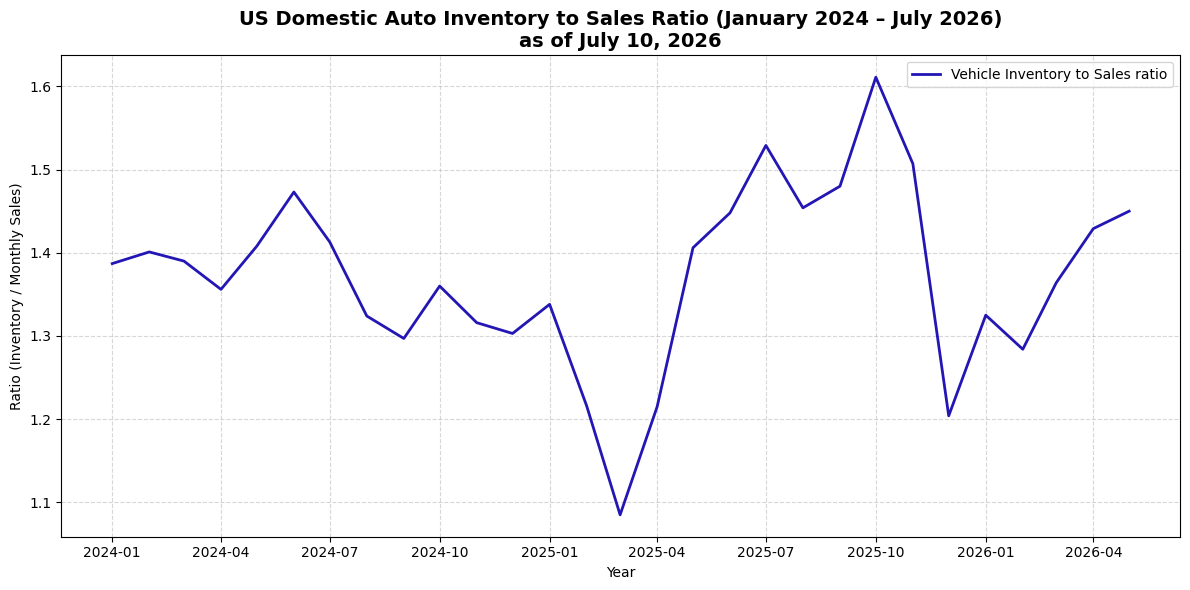

In [4]:
df = web.DataReader('AISRSA', 'fred', start, end)

# Plotting
plt.figure(figsize = (12, 6))
plt.plot(df.index, df["AISRSA"], label = 'Vehicle Inventory to Sales ratio', color = "#2316b4", linewidth = 2)


plt.title(f'US Domestic Auto Inventory to Sales Ratio ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', 
          fontsize = 14, 
          fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Ratio (Inventory / Monthly Sales)')

plt.grid(True, which = 'both', linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()
    
plt.show()

### U.S. Domestic Vehicle Inventory vs. Monthly Moving Average (2024 - Present)

<Figure size 1600x600 with 0 Axes>

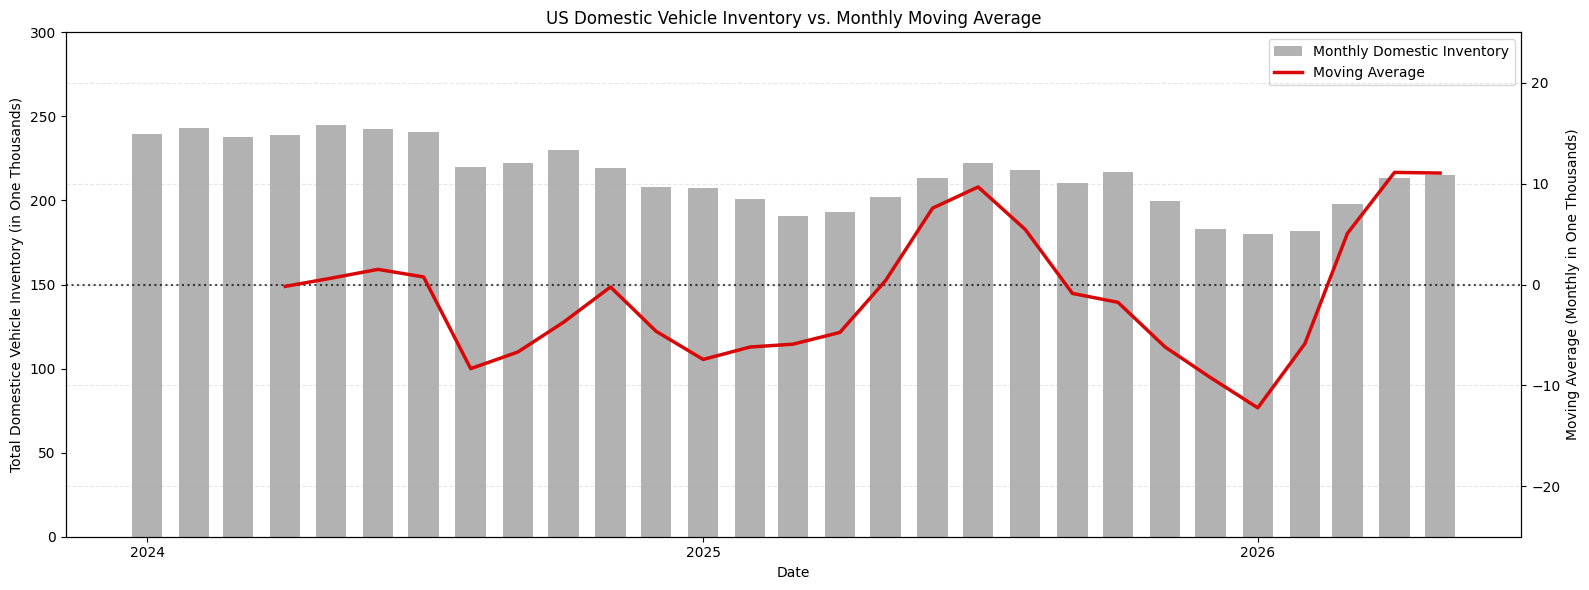

In [5]:
# Source : FRED
df = web.DataReader("AUINSA", "fred", start, end)

df["domestic_inv"] = df["AUINSA"].diff()
df["ma_3"] = df["domestic_inv"].rolling(3).mean()

df_focus = df[(df.index >= start)]

plt.figure(figsize = (16, 6)) 

fig, ax1 = plt.subplots(figsize = (16, 6))

# inventory bar graph
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Domestice Vehicle Inventory (in One Thousands)", color = "black")
ax1.tick_params(axis = "y", labelcolor = "black")
ax1.set_ylim(0, 300)
ax1.bar(
    df_focus.index,
    df_focus["AUINSA"],
    color = "grey",
    width = 20,
    alpha = 0.6,
    label = "Monthly Domestic Inventory",
)

# copy left axis
ax2 = ax1.twinx()

# inventory moving average
ax2.set_ylabel("Moving Average (Monthly in One Thousands)", color = "black")
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.axhline(0, color = "black", linestyle = ":", linewidth = 1.5, alpha = 0.7)
ax2.set_ylim(-25, 25)
ax2.plot(
    df_focus.index,
    df_focus["ma_3"],
    color = "#d90808",
    linewidth = 2.5,
    label = "Moving Average",
)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.title(  
    "US Domestic Vehicle Inventory vs. Monthly Moving Average"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")

plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
fig.tight_layout()

plt.show()


### U.S Total Domestic Vehicle Sales and Moving Average (Janaury 2024 - Present)

<Figure size 1600x600 with 0 Axes>

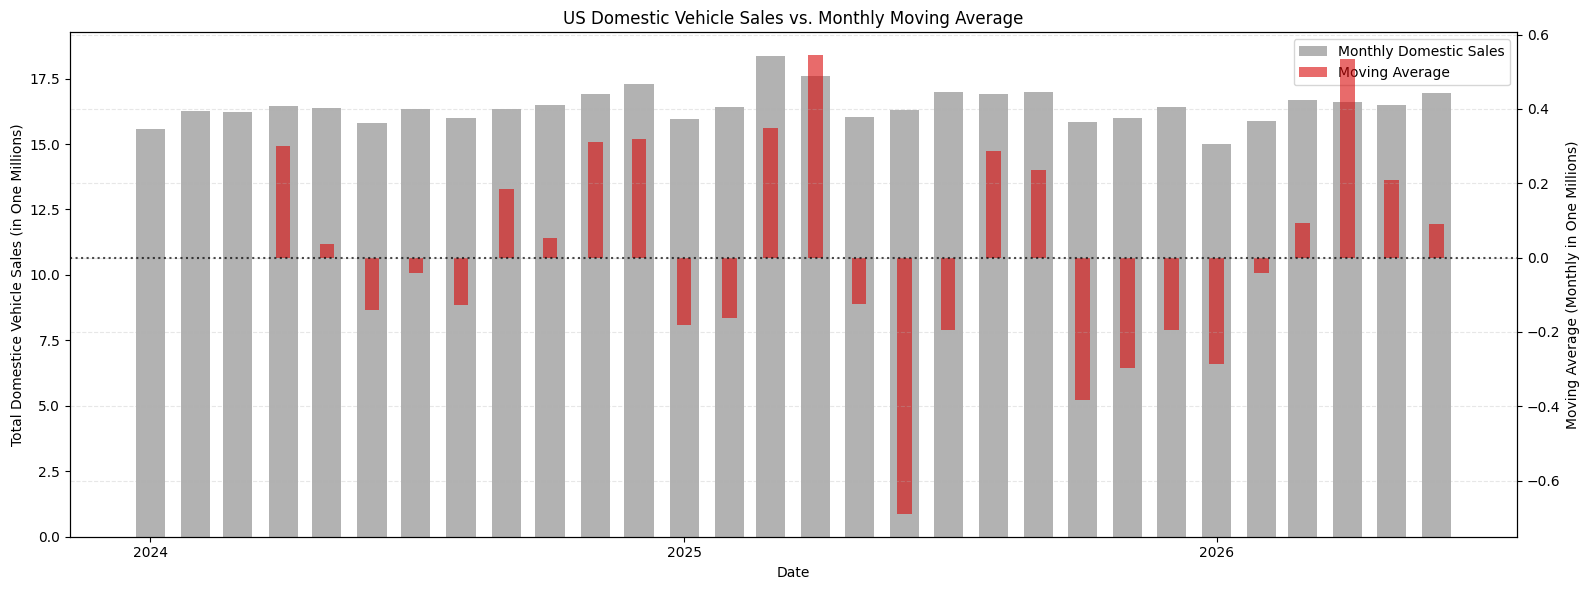

In [6]:
# Source : FRED
df = web.DataReader("TOTALSA", "fred", start, end)

df["salestot"] = df["TOTALSA"].diff()
df["ma_3"] = df["salestot"].rolling(3).mean()

df_focus = df[(df.index >= start)]

plt.figure(figsize = (16, 6)) 

fig, ax1 = plt.subplots(figsize = (16, 6))

# inventory bar graph
ax1.set_xlabel("Date")
ax1.set_ylabel("Total Domestice Vehicle Sales (in One Millions)", color = "black")
ax1.tick_params(axis = "y", labelcolor = "black")
#ax1.set_ylim(200000, 1600000)
ax1.bar(
    df_focus.index,
    df_focus["TOTALSA"],
    color = "grey",
    width = 20,
    alpha = 0.6,
    label = "Monthly Domestic Sales",
)

# copy left axis
ax2 = ax1.twinx()

# inventory moving average
ax2.set_ylabel("Moving Average (Monthly in One Millions)", color = "black")
ax2.tick_params(axis = "y", labelcolor = "black")
ax2.axhline(0, color = "black", linestyle = ":", linewidth = 1.5, alpha = 0.7)
ax2.bar(
    df_focus.index,
    df_focus["ma_3"],
    color = "#d90808",
    width = 10,
    alpha = 0.6,
    label = "Moving Average",
)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.title(  
    "US Domestic Vehicle Sales vs. Monthly Moving Average"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")

plt.grid(axis = "y", linestyle = "--", alpha = 0.3)
fig.tight_layout()

plt.show()


### U.S. New Vehicle Price Inflation (January 2025 - Present)

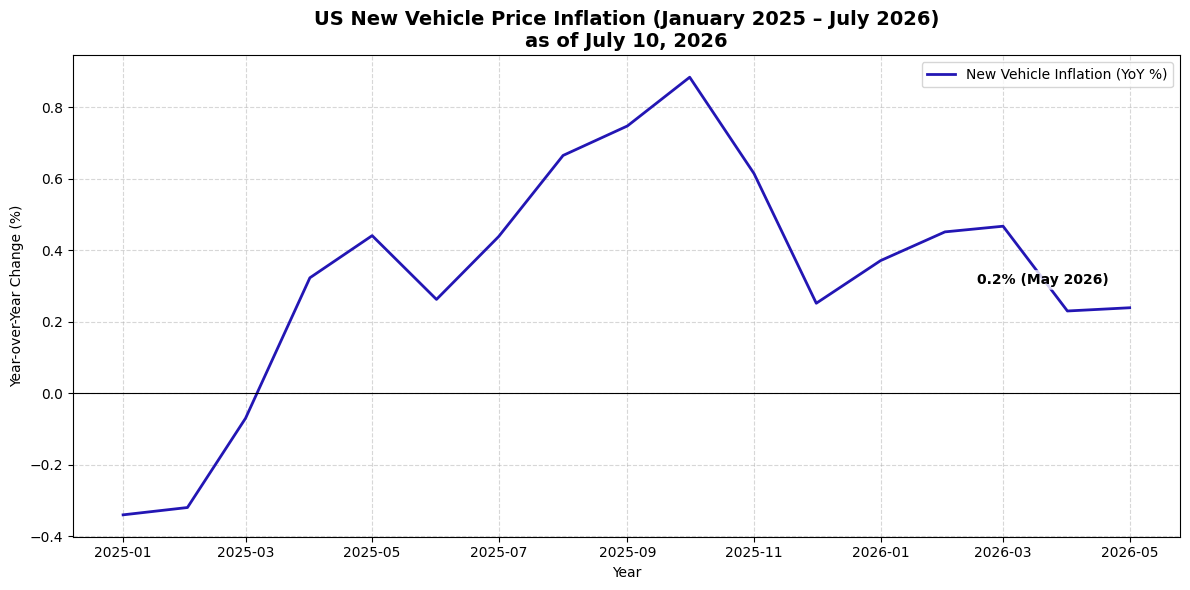

In [7]:
# Source : FRED
df_vehicle_cpi = web.DataReader('CUSR0000SETA01', 'fred', start, end)
df_yoy = df_vehicle_cpi.pct_change(periods = 12) * 100

# Plotting
plt.figure(figsize = (12, 6))

plt.plot(df_yoy.index, df_yoy["CUSR0000SETA01"], label = 'New Vehicle Inflation (YoY %)', color = "#2316b4", linewidth = 2)

df_rate = df_yoy["CUSR0000SETA01"].dropna()
latest_date = df_rate.index[-1]
latest_val = df_rate.iloc[-1]
    
plt.title(f'US New Vehicle Price Inflation ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Year-over-Year Change (%)') 

plt.axhline(0, color = 'black', linewidth = 0.8, linestyle = '-')
plt.grid(True, which = 'both', linestyle = '--', alpha = 0.5)
plt.legend()
plt.tight_layout()

plt.annotate(f"{latest_val:.1f}% ({latest_date.strftime('%b %Y')})", 
            (latest_date, latest_val), 
            textcoords="offset points", 
            xytext=(-15, 15), 
            ha='right', 
            va='bottom',
            weight='bold', 
            color='black',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))

plt.show()

# Conclusions and Observations

#### Automotive - 10 July 2026

The auttomtive industry is nott under fire as some would have you believe. It's under a lot of pressure.

Over the pastt 12 months, auto sales have show a significant decline through 2026 so far.

With the absecne of subisdies and increase in auto import tariffs, sales have generally softened.

#### Home on the range

Domestic vehicle prices have grown marignally, at just 0.2% year of year in May 2026. 

Month-to-month, inventory-to-sale ratio has increased since Q4 2025.

In the same period. domestic inventory has grown. 

Meaning that fewer cars are selling, sellers have growing inventories, and MSRP prices are not holding.

At least for vehicles manufacttured in tthe United States.

#### Foregin automakers and sellers introdcue limitrd inventories to the United States at representative values

Might want to look into buying a camel.

The domestic auto industry in the United States is by no means in trouble.

It is by all means shrinking in shares of the market. 

Much like any product in a free market, monopolies are unlikely to form.

Instead, market competition and pricing competition promote sales by foreign retailers.

Letting the owner of the Honda Civic swap into a 4-Runner when they move into a differentt climate.

America needs the market flexibility provided by foreign importers in order to meet the needs of the consumers.

Foreign sellers have greater accewss to their sales numbers than any one of us.

They know we need to buy these vehicles. 

That or we start bussing kids to school in yellow pickups.

___

**Thank you for reading. If you're able to walk from place to place, you're one of the lucky ones. The rest of us would rather not take our sweet time on the highway.**

**<u>U.S. National Gas Pricess</u> and <u>U.S. Grocery Supply Chains</u> made the cut this week. Swing around for what's on the chopping block.**
___


#### Update Schedule

- ***Auto Indicators - Jul 30, 2026***

    1. `AISRSA`: **Domestic Auto Inventory to Sales Ratio (Monthly)**
    2. `AUINSA`: **Domestic Vehicle Inventory (Monthly, Thousands)**
    3. `TOTALSA`: **Total Vehicle Sales (Monthly, Millions, SAAR)**

- ***Consumer Price Index - Jul 14, 2026***

    4. `CUSR0000SETA01`: **New Vehicles (Monthly)**

#### Data Changelog / Notes

#### ***Review and analysis publishing on Friday, August 14, 2026, at 1:30 P.M. Pacific Time.***